In [40]:
import os
from typing import Annotated, Sequence, TypedDict
from typing import Literal
from uuid import uuid4

import chromadb
from dotenv import load_dotenv
from langchain import hub
from langchain.chains import RetrievalQA
from langchain.chains import RetrievalQA
from langchain.document_loaders import PyPDFLoader
from langchain.text_splitter import CharacterTextSplitter
from langchain.tools.retriever import create_retriever_tool
from langchain_anthropic import ChatAnthropic
from langchain_chroma import Chroma
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_core.pydantic_v1 import BaseModel, Field
from langchain_huggingface import HuggingFaceEmbeddings
from langgraph.graph.message import add_messages
from langgraph.prebuilt import tools_condition


In [41]:
DOC_DIR = "../documents"
DOC_TYPE = "LSTA"
EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"
LLM_MODEL_NAME = "claude-3-5-sonnet-20241022"  # Cloud LLM with Anthropic Claude
CHUNK_SIZE = 4096
CHUNK_OVERLAP = 512
PURGE_VECTOR_DB = False

In [42]:
# Load environment variables from the .env file
load_dotenv()
LANGSMITH_API_KEY = os.getenv('LANGSMITH_API_KEY')

In [22]:
# device = torch.device("cuda:0" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL_NAME)
collection_name = "rag_collection_lsta"
chroma_client = chromadb.PersistentClient()

try:
    if PURGE_VECTOR_DB:  # Keep option for hard reset
        chroma_client.delete_collection(name=collection_name)
    chroma_client.get_or_create_collection(collection_name)
except ValueError:
    chroma_client.delete_collection(collection_name)

collection = chroma_client.get_or_create_collection(collection_name)

vector_store = Chroma(
    client=chroma_client,
    collection_name=collection_name,
    embedding_function=embeddings
)
retriever = vector_store.as_retriever()

In [36]:
# Split the document into chunks
def insert_document_to_vector_db(doc_path):
    loader = PyPDFLoader(doc_path)
    documents = loader.load()
    text_splitter = CharacterTextSplitter(chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP, separator="\n")
    docs = text_splitter.split_documents(documents=documents)
    uuids = [str(uuid4()) for _ in range(len(docs))]
    # print(len(uuids))
    ids = vector_store.add_documents(documents=docs, ids=uuids)
    return ids

In [37]:
dir_path = os.path.join(DOC_DIR, DOC_TYPE)
vector_indices = []
if os.path.exists(dir_path) and os.path.isdir(dir_path):
    temp_indices = [insert_document_to_vector_db(os.path.join(dir_path, doc))
                    for doc in os.listdir(dir_path)
                    if doc != '.DS_Store'
                    ]
    # if doc in file_list]
    vector_indices.extend(temp_indices)
#vector_indices

[['d0f90e41-9a02-420a-993f-db9395be884a',
  '3953204e-4d59-41cf-9e67-ed0f97cc70b5',
  '95c2d791-0483-437a-aa1b-35d26d2dd4a2',
  'db1de032-b690-4e1e-abdb-44b0a0c92610',
  'a3d1c28b-383f-4ec7-9eff-8beb59f76e0a',
  '1a324c18-57e5-4f85-8baf-57b0d9ec800d',
  '85da95e9-8558-4337-bd57-934b5ceedea3',
  '9fff05ab-6dd0-45fb-9781-41eb25745618',
  '0eedcd9b-7b1a-4421-b1ff-dea5bc347ba7',
  '124c110d-2211-4101-ad1d-1d83ed0fe36e',
  '025649c7-c277-4c84-ba14-0388e9adbf35',
  '7c120279-0dae-4498-a657-6dbdb1d0db51',
  'b2e33e89-ebc3-47ef-8230-d7ef345f2d7a',
  '84f28f9f-31cc-4f4f-b9fb-fcb078082257',
  '4832bc64-8246-41c9-9507-0c232d44c3b0',
  '6ad85ebb-39b6-447e-a5fa-93016cea5e5d',
  '7c05b561-cc02-4037-8df0-10e8c49b3b1c',
  'c8b7a8c9-0c9e-438b-8351-8eef1eb65576',
  'a40c9356-c245-41d1-98ab-2b1d13f12b90'],
 ['4cb0c5ac-ddd5-4eab-bb66-f95bf4f28ef9',
  '20bf5eb5-c2f6-4baa-a7a8-2ee833261697',
  '0fb9bc2f-8741-4aee-a0c4-1843754d0304',
  '0a9237c4-2433-4367-9850-f84945016354',
  '97922f42-9b40-4882-9065-be3905

In [38]:
retriever_tool = create_retriever_tool(
    retriever,
    "retrieve_lsta_docs",
    "Search and return information about Sustainability Linked Loan Principles from LSTA documents.",
)

tools = [retriever_tool]

In [45]:
# retriever_tool.invoke(
#     {"query": "Search and return information about Sustainability Linked Loan Principles from LSTA documents.?"})

In [26]:
class AgentState(TypedDict):
    # The add_messages function defines how an update should be processed
    # Default is to replace. add_messages says "append"
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [27]:
### Edges
def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.
    Args:
        state (messages): The current state
    Returns:
        str: A decision for whether the documents are relevant or not
    """
    print("---CHECK RELEVANCE---")

    # Data model
    class grade(BaseModel):
        """Binary score for relevance check."""
        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # LLM
    model = ChatAnthropic(temperature=0, model_name=LLM_MODEL_NAME, streaming=True)
    # LLM with tool and validation
    llm_with_tool = model.with_structured_output(grade)
    # Prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )

    # Chain
    chain = prompt | llm_with_tool
    messages = state["messages"]
    print(f"Messages: {messages}")
    last_message = messages[-1]
    question = messages[0].content
    print(f"Question: {question}")
    docs = last_message.content
    print(f"Docs: {docs}")

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"

    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"


In [44]:
### Nodes
def agent(state):
    """
    Invokes the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """
    print("---CALL AGENT---")
    messages = state["messages"]
    model = ChatAnthropic(temperature=0, streaming=True, model_name=LLM_MODEL_NAME)
    model = model.bind_tools(tools)
    response = model.invoke(messages)
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}


def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n
    Look at the input and try to reason about the underlying semantic intent / meaning. \n
    Here is the initial question:
    \n ------- \n
    {question}
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    model = ChatAnthropic(model_name=LLM_MODEL_NAME, temperature=0, streaming=True)

    response = model.invoke(msg)
    return {"messages": [response]}


def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated state with re-phrased question
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt
    prompt = hub.pull("rlm/rag-prompt")

    # LLM
    llm = ChatAnthropic(model_name=LLM_MODEL_NAME, temperature=0, streaming=True)

    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}


print("*" * 20 + "Prompt[rlm/rag-prompt]" + "*" * 20)
prompt = hub.pull("rlm/rag-prompt").pretty_print()  # Show what the prompt looks like

********************Prompt[rlm/rag-prompt]********************
================================ Human Message =================================

You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: {question} 
Context: {context} 
Answer:


/Users/peeyushsharma/opt/anaconda3/envs/llm_venv/lib/python3.9/site-packages/langsmith/client.py:272: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [29]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode

# Define a new graph
workflow = StateGraph(AgentState)

# Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent
retrieve = ToolNode([retriever_tool])
workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # Re-writing the question
workflow.add_node(
    "generate", generate
)  # Generating a response after we know the documents are relevant
# Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile
graph = workflow.compile()

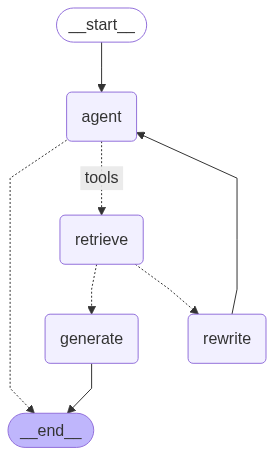

In [30]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [31]:
import pprint

inputs = {
    "messages": [
        ("user",
         "What are some of the main challenges in application of Sustainability Linked Loan Principles (SLLP) to fund finance facilities?"),
    ]
}
for output in graph.stream(inputs):
    for key, value in output.items():
        pprint.pprint(f"Output from node '{key}':")
        pprint.pprint("---")
        pprint.pprint(value, indent=2, width=80, depth=None)
    pprint.pprint("\n---\n")

---CALL AGENT---
"Output from node 'agent':"
'---'
{ 'messages': [ AIMessage(content=[{'text': "I'll search for information about challenges in applying SLLP to fund finance facilities.", 'type': 'text', 'index': 0}, {'id': 'toolu_01NooVm7oZP4cEuxrbgHabzT', 'input': {}, 'name': 'retrieve_lsta_docs', 'type': 'tool_use', 'index': 1, 'partial_json': '{"query": "challenges application SLLP fund finance facilities"}'}], additional_kwargs={}, response_metadata={'model_name': 'claude-3-5-sonnet-20241022', 'stop_reason': 'tool_use', 'stop_sequence': None}, id='run--90c58248-ee45-4e4e-800a-ec9ece57860b-0', tool_calls=[{'name': 'retrieve_lsta_docs', 'args': {'query': 'challenges application SLLP fund finance facilities'}, 'id': 'toolu_01NooVm7oZP4cEuxrbgHabzT', 'type': 'tool_call'}], usage_metadata={'input_tokens': 430, 'output_tokens': 83, 'total_tokens': 513, 'input_token_details': {'cache_creation': 0, 'cache_read': 0}})]}
'\n---\n'
---CHECK RELEVANCE---
Messages: [HumanMessage(content='What 